In [ ]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt

from pywk99.timeseries.timeseries import remove_linear_trend
from pywk99.spectrum import get_window_spectra
from pywk99.significance import log_distance_statistic
from pywk99.significance import permutation_difference_test

In [10]:
ds = xr.open_dataset("/work/mh0081/m301047/data/iolr/noaa_olr.2xdaily.1979-2022.nc", engine='netcdf4')
olr_a = ds.olr.sel(time=slice("1979-01", "1982-12", None), lat=slice(15,-15, None)).sortby("lat")
olr_b = ds.olr.sel(time=slice("1980-01", "1983-12", None), lat=slice(15,-15, None)).sortby("lat")
olr_a = remove_linear_trend(olr_a)
olr_b = remove_linear_trend(olr_b)

In [11]:
spc_quantity = "power"
window_length = "92D"
overlap_length = "0D"
data_frequency = "12h"
component_type = "symmetric"
spectra_a = get_window_spectra(spc_quantity, olr_a, component_type, data_frequency,
                               window_length, overlap_length)
spectra_b = get_window_spectra(spc_quantity, olr_b, component_type, data_frequency,
                               window_length, overlap_length)

### Bootstrap 

In [12]:
alpha = 5/100
resamplings = 1000
smooth_passes = 1
statistic = "log_distance"
observed_log_distance = log_distance_statistic(spectra_a, spectra_b)
permutation_results =  permutation_difference_test(spectra_a,
                                                   spectra_b,
                                                   statistic,
                                                   alpha=alpha,
                                                   resamplings=resamplings,
                                                   smooth_passes=smooth_passes)

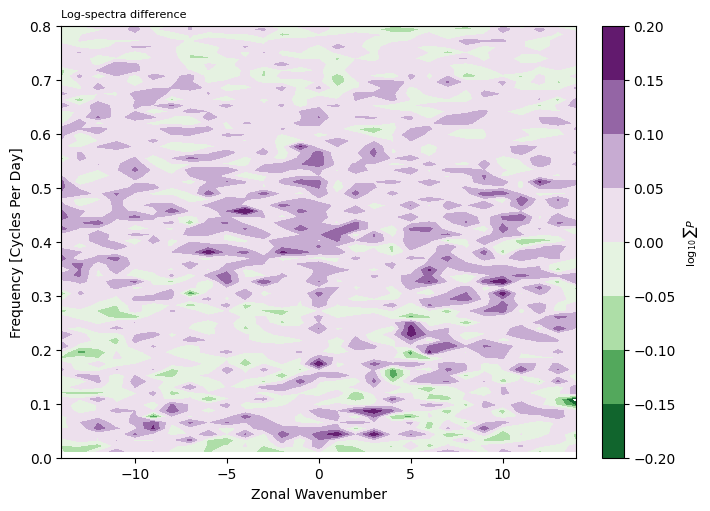

In [13]:
fig, ax = plt.subplots(1 , 1, figsize=(7, 5), constrained_layout=True)
plt.rcParams['hatch.linewidth'] = 0.5

diff = observed_log_distance.values
significant = permutation_results.significant.values
k = observed_log_distance.wavenumber
w = observed_log_distance.frequency
levels = np.arange(-0.2, 0.25, 0.05)

cs = ax.contourf(k, w, diff, levels, cmap="PRGn_r")
ax.contourf(k, w, permutation_results.significant,
            levels=3,
            hatches=['', '///\\\\\\'],
            cmap="Greys",
            alpha=0.025)
ax.set_xlabel("Zonal Wavenumber")
ax.set_ylabel("Frequency [Cycles Per Day]")
ax.set_title("Log-spectra difference",  fontsize=8, loc='left')
ax.set_xlim(-14, 14)
ax.set_ylim(0, 0.8)
cb = fig.colorbar(cs, ax=ax)
cb.set_label(r"$\log_{10}{\sum P}$", fontsize=8)